In [1]:
# Cell 1 — imports and paths
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

RESULTS_ROOT = Path("../results")
LANGS = ["en", "de", "fr", "nl"]
SEEDS = [42, 123, 456]

In [2]:
# Cell 2 — load hard routing data and compute confusion matrix
hard_matrices = []

for seed in SEEDS:
    path = RESULTS_ROOT / "moe_hard" / f"seed{seed}" / "routing.json"
    with open(path) as f:
        routing_data = json.load(f)

    matrix = np.zeros((4, 4))
    for i, src_lang in enumerate(LANGS):
        entries = routing_data[src_lang]
        for e in entries:
            j = LANGS.index(e["top_expert"])
            matrix[i, j] += 1
        matrix[i] /= matrix[i].sum()

    hard_matrices.append(matrix)

hard_mean = np.mean(hard_matrices, axis=0) * 100
print("Hard routing confusion matrix (%):")
print(np.round(hard_mean, 1))

Hard routing confusion matrix (%):
[[86.6  0.   0.6 12.8]
 [11.5 39.4  1.4 47.7]
 [ 9.   1.5 47.5 42.1]
 [ 9.6  8.1  2.1 80.1]]


In [3]:
# Cell 3 - confusion matrix explanation
print("\nConfusion Matrix: rows=source language, cols=routed expert")
print("\nPer-language accuracy:")
for i, lang in enumerate(LANGS):
    print(f"{lang}: {hard_mean[i, i]:.1f}%")

print("\nMajor misrouting:")
for i in range(4):
    for j in range(4):
        if i != j and hard_mean[i, j] > 20:
            print(f"{LANGS[i]} to {LANGS[j]}: {hard_mean[i, j]:.1f}%")


Confusion Matrix: rows=source language, cols=routed expert

Per-language accuracy:
en: 86.6%
de: 39.4%
fr: 47.5%
nl: 80.1%

Major misrouting:
de to nl: 47.7%
fr to nl: 42.1%


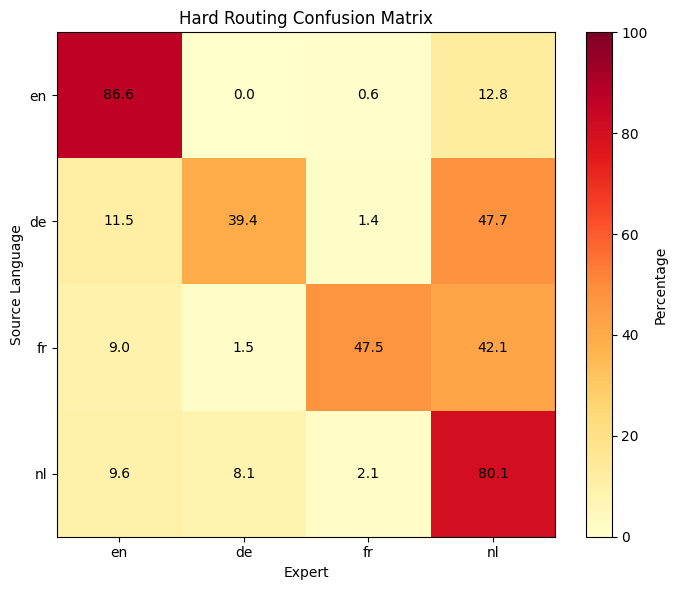

In [4]:
# Cell 4 - heatmap visualization
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(hard_mean, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(LANGS)
ax.set_yticklabels(LANGS)
ax.set_xlabel('Expert')
ax.set_ylabel('Source Language')
ax.set_title('Hard Routing Confusion Matrix')

for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{hard_mean[i, j]:.1f}',
                ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=ax, label='Percentage')
plt.tight_layout()
plt.show()

In [5]:
# Cell 5 - statistics
overall_acc = np.trace(hard_mean) / 4
print(f"Overall accuracy: {overall_acc:.1f}%")
print(f"\nPer-language accuracy:")
for i, lang in enumerate(LANGS):
    print(f"{lang}: {hard_mean[i, i]:.1f}%")

Overall accuracy: 63.4%

Per-language accuracy:
en: 86.6%
de: 39.4%
fr: 47.5%
nl: 80.1%
